In [166]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from scipy import stats
import plotly.graph_objects as go

ticker="RELIANCE.NS"
data=yf.download(ticker,start="2018-01-01",end="2026-05-01",progress=False)

print(data.head())

price=data['Close'].squeeze()
log_returns=np.log(price/price.shift(1)).dropna()


print(f"\nLoaded {len(log_returns)} trading days")
print(f"Period: {log_returns.index[0].date()} "
      f"to {log_returns.index[-1].date()}")
print(f"\n{log_returns}")

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2018-01-01  400.015289  405.709363  399.025968  405.709363     9453202
2018-01-02  400.630859  404.324335  398.542295  401.444307     9499419
2018-01-03  402.235748  407.160372  401.466269  406.720658    13507800
2018-01-04  404.654053  405.313610  402.631441  403.708700     9008932
2018-01-05  405.951233  407.556144  404.632147  405.313689     7441284

Loaded 2055 trading days
Period: 2018-01-02 to 2026-04-30

Date
2018-01-02    0.001538
2018-01-03    0.003998
2018-01-04    0.005994
2018-01-05    0.003201
2018-01-08    0.005724
                ...   
2026-04-24   -0.011680
2026-04-27    0.028217
2026-04-28    0.016772
2026-04-29    0.025940
2026-04-30    0.003781
Name: RELIANCE.NS, Length: 2055, dtype: float64


/var/folders/j2/gw4b0qqs0q1fvcyp3bj_6f8r0000gn/T/ipykernel_85224/1738867412.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



In [168]:
df=pd.DataFrame(index=log_returns.index)
df['returns'] = log_returns
print(df.shape)

(2055, 1)


In [170]:
#ADDING RETURNS FEATURES
# Previous day's return — did market go up or down yesterday?
# .shift(1) ensures we only use PAST information
df['return_lag1'] = df['returns'].shift(1)
df['return_lag2'] = df['returns'].shift(2)

# Rolling returns — short and medium term momentum
df['rolling_return_5d']  = df['returns'].shift(1).rolling(5).mean()
df['rolling_return_20d'] = df['returns'].shift(1).rolling(20).mean()


#ADDING VOLATILITY FEATURES
# Rolling volatility at three horizons
# Short: 5 days | Medium: 20 days | Long: 60 days
df['rolling_vol_5d']  = df['returns'].shift(1).rolling(5).std()
df['rolling_vol_20d'] = df['returns'].shift(1).rolling(20).std()
df['rolling_vol_60d'] = df['returns'].shift(1).rolling(60).std()
df['vol_spike'] = df['rolling_vol_5d'] / df['rolling_vol_20d']

df['vol_ratio']=df['rolling_vol_5d']/df['rolling_vol_60d']

#adding GARCH(1,1) to find garch conditional volality

scaled=log_returns*100
garch_model=arch_model(scaled,vol='garch',p=1,q=1,mean='Constant', dist='normal')
garch_result = garch_model.fit(disp='off')

cond_vol = garch_result.conditional_volatility / 100 

# CRITICAL: shift(1) — use yesterday's GARCH estimate
# to predict today's violation
df['garch_vol'] = cond_vol.shift(1) #this is also a feature 
df['garch_vol_change'] = df['garch_vol'].pct_change() #this is also a feature


In [172]:
#ADDING TARGET VARIABLES

# Historical VaR at 95% confidence (5th percentile)
# .shift(1) ensures today's return is NOT included in the threshold —
# threshold at t uses only returns[t-252 : t-1]
rolling_var = df['returns'].rolling(252).apply(lambda x: np.percentile(x, 5)).shift(1)

df['var_threshold'] = rolling_var
df['violation'] = (df['returns'] < df['var_threshold']).astype(int)

print("\nTarget variable created")
print(f"Total violations: {df['violation'].sum()}")
print(f"Violation rate: {df['violation'].mean()*100:.2f}%")
print(f"Expected rate: 5%")


Target variable created
Total violations: 97
Violation rate: 4.72%
Expected rate: 5%


In [174]:
##ADDING REMAINING FEATURES
df['yesterday_violation'] = df['violation'].shift(1) 

df['garch_vol_zscore'] = (
    (df['garch_vol'] - df['garch_vol'].rolling(60).mean()) /
    df['garch_vol'].rolling(60).std()
)

# Worst return over past 5 days
df['max_drawdown_5d'] = df['returns'].shift(1).rolling(5).min().abs()

print(df.head())

             returns  return_lag1  return_lag2  rolling_return_5d  \
Date                                                                
2018-01-02  0.001538          NaN          NaN                NaN   
2018-01-03  0.003998     0.001538          NaN                NaN   
2018-01-04  0.005994     0.003998     0.001538                NaN   
2018-01-05  0.003201     0.005994     0.003998                NaN   
2018-01-08  0.005724     0.003201     0.005994                NaN   

            rolling_return_20d  rolling_vol_5d  rolling_vol_20d  \
Date                                                              
2018-01-02                 NaN             NaN              NaN   
2018-01-03                 NaN             NaN              NaN   
2018-01-04                 NaN             NaN              NaN   
2018-01-05                 NaN             NaN              NaN   
2018-01-08                 NaN             NaN              NaN   

            rolling_vol_60d  vol_spike  vol_ra

In [176]:
# 3. CLEANING DATA 
df_clean = df.dropna().copy()

# Convert yesterday_violation to int now that NaNs are dropped safely
df_clean['yesterday_violation'] = df_clean['yesterday_violation'].astype(int)

print("Remaining features added without data leakage.")
df_clean

Remaining features added without data leakage.


,returns,return_lag1,return_lag2,rolling_return_5d,rolling_return_20d,rolling_vol_5d,rolling_vol_20d,rolling_vol_60d,vol_spike,vol_ratio,garch_vol,garch_vol_change,var_threshold,violation,yesterday_violation,garch_vol_zscore,max_drawdown_5d
Date,,,,,,,,,,,,,,,,,
2019-01-10,-0.002930,0.005507,-0.000091,0.000785,0.000598,0.007762,0.010650,0.017004,0.728844,0.456492,0.012854,-0.032604,-0.025823,0,0,-1.283169,0.012414
2019-01-11,-0.008569,-0.002930,0.005507,0.002682,-0.000135,0.003957,0.010344,0.016388,0.382505,0.241429,0.012556,-0.023188,-0.025823,0,0,-1.330770,0.002930
2019-01-14,-0.001139,-0.008569,-0.002930,-0.000109,-0.000408,0.005978,0.010497,0.016346,0.569492,0.365717,0.012254,-0.024027,-0.025823,0,0,-1.387673,0.008569
2019-01-15,0.029511,-0.001139,-0.008569,-0.001444,-0.000697,0.005080,0.010430,0.016101,0.487028,0.315505,0.012273,0.001531,-0.025823,0,0,-1.362253,0.008569
2019-01-16,0.005517,0.029511,-0.001139,0.004476,-0.000011,0.014869,0.011917,0.016520,1.247709,0.900073,0.011967,-0.024945,-0.025823,0,0,-1.409399,0.008569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,-0.011680,-0.013824,0.006481,0.000015,-0.002575,0.011680,0.019240,0.015691,0.607052,0.744358,0.016234,-0.042238,-0.020555,0,0,0.093764,0.013824
2026-04-27,0.028217,-0.011680,-0.013824,-0.005526,-0.002925,0.008255,0.019344,0.015754,0.426765,0.524001,0.016122,-0.006896,-0.020555,0,0,0.041972,0.013824
2026-04-28,0.016772,0.028217,-0.011680,0.000366,-0.001656,0.017459,0.020537,0.016129,0.850104,1.082482,0.015854,-0.016655,-0.020555,0,0,-0.088708,0.013824


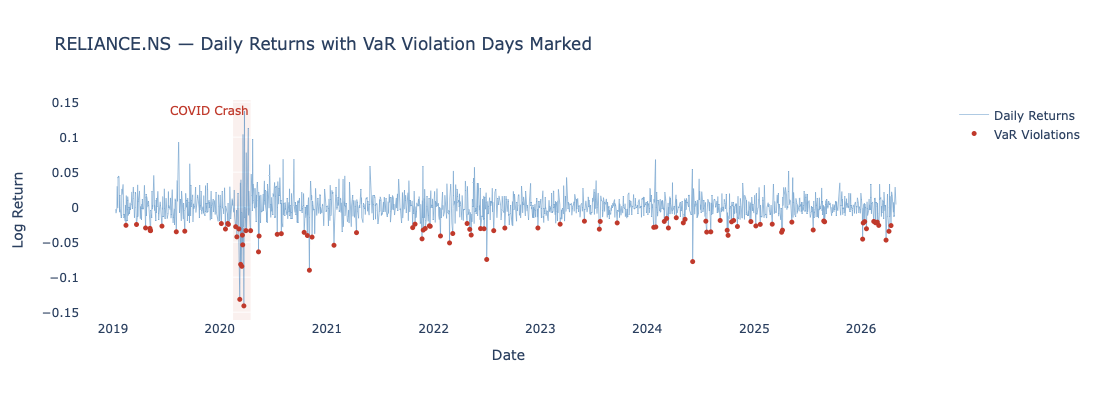


Violation clustering check:
Violations in 2020: 23
Violations in 2019 (calm): 9


In [178]:
# Plotting returns with violation days marked
# This is your sanity check — violation days should cluster
# around March 2020 and other volatile periods
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_clean.index,
    y=df_clean['returns'],
    mode='lines',
    name='Daily Returns',
    line=dict(color='#2e75b6', width=0.8),
    opacity=0.6
))

violations_only = df_clean[df_clean['violation'] == 1]
fig.add_trace(go.Scatter(
    x=violations_only.index,
    y=violations_only['returns'],
    mode='markers',
    name='VaR Violations',
    marker=dict(color='#c0392b', size=5)
))

fig.add_vrect(
    x0="2020-02-15", x1="2020-04-15",
    fillcolor="rgba(192,57,43,0.08)",
    layer="below", line_width=0,
    annotation_text="COVID Crash",
    annotation_font_color="#c0392b"
)

fig.update_layout(
    title='RELIANCE.NS — Daily Returns with VaR Violation Days Marked',
    xaxis_title='Date',
    yaxis_title='Log Return',
    paper_bgcolor='white',
    plot_bgcolor='white',
    height=400
)
fig.show()

# Crucial Step: Ensure index is datetime format
df_clean.index = pd.to_datetime(df_clean.index)

print(f"\nViolation clustering check:")
# Use .loc to slice years safely from the index
print(f"Violations in 2020: "
      f"{df_clean.loc['2020', 'violation'].sum()}")
print(f"Violations in 2019 (calm): "
      f"{df_clean.loc['2019', 'violation'].sum()}")


In [8]:
!pip install xgboost


zsh:1: command not found: pip


In [180]:
# IMPLMENTING XGBOOST

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score,roc_curve,precision_recall_curve,confusion_matrix

X=df_clean.drop(['returns','violation','var_threshold'],axis=1)
y=df_clean['violation']

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nClass distribution:")
print(f"  Normal days (0):    {(y==0).sum()} "
      f"({(y==0).mean()*100:.1f}%)")
print(f"  Violation days (1): {(y==1).sum()} "
      f"({(y==1).mean()*100:.1f}%)")

#computing the scale_pos_weight
neg_count=(y==0).sum()
pos_count=(y==1).sum()
scale_pos_weight=neg_count/pos_count

print(f"\nNegative class (normal):    {neg_count}")
print(f"Positive class (violation): {pos_count}")
print(f"scale_pos_weight:           {scale_pos_weight:.2f}")
print(f"\nInterpretation: Each violation day will be weighted "
      f"{scale_pos_weight:.1f}x heavier than a normal day")

Feature matrix: (1803, 14)
Target: (1803,)

Class distribution:
  Normal days (0):    1706 (94.6%)
  Violation days (1): 97 (5.4%)

Negative class (normal):    1706
Positive class (violation): 97
scale_pos_weight:           17.59

Interpretation: Each violation day will be weighted 17.6x heavier than a normal day


In [182]:
#hyperparamter tuning to find the best parameters for the model
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


param_grid = {
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [100, 200, 300],
    'subsample':     [0.7, 0.8, 0.9]
}

base_model = XGBClassifier()

# Use TimeSeriesSplit — NOT regular cross-validation
# Regular CV would leak future data into training
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,         # use all CPU cores
    verbose=1
)

grid_search.fit(X, y)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validated AUC-ROC: "
      f"{grid_search.best_score_:.4f}")

# Use the best model going forward
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best hyperparameters found:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Best cross-validated AUC-ROC: 0.4720


In [11]:
model = XGBClassifier(
    # Tree structure — shallow trees to avoid memorising noise
    n_estimators=300,
    max_depth=3,           # reduced from 5: limits tree complexity
    min_child_weight=5,    # each leaf must contain ≥5 samples: prevents splits on tiny violation clusters

    # Learning
    learning_rate=0.01,

    # Regularisation
    subsample=0.8,
    colsample_bytree=0.8,

    # Class imbalance fix
    scale_pos_weight=scale_pos_weight,

    # Reproducibility
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

from sklearn.model_selection import cross_val_score
tscv = TimeSeriesSplit(n_splits=5)

fold_scores = cross_val_score(model, X, y, cv=tscv, scoring='roc_auc')

print("Per-fold AUC-ROC scores:")
for i, s in enumerate(fold_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean AUC-ROC: {fold_scores.mean():.4f}")
print(f"Std  AUC-ROC: {fold_scores.std():.4f}")

Per-fold AUC-ROC scores:
  Fold 1: 0.3636
  Fold 2: 0.4728
  Fold 3: 0.4065
  Fold 4: 0.4315
  Fold 5: 0.6038

Mean AUC-ROC: 0.4556
Std  AUC-ROC: 0.0821


In [12]:
# After cross-validation, refit on ALL data
# This gives the strongest model for the Streamlit app
model.fit(X, y)
print("Model refit on full dataset — ready for deployment")
print(f"Final model: {model.n_estimators} trees, "
      f"depth {model.max_depth}")

#plotting the ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
y_pred_proba = model.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_pred_proba)

# Step 4 — Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name='XGBoost — Train AUC'
))
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    name='Random Classifier',
    line=dict(color='grey', dash='dash')
))
fig.update_layout(
    title=f'ROC Curve | Cross-validated AUC: ',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    paper_bgcolor='white', plot_bgcolor='white',
    height=450
)
fig.show()




Model refit on full dataset — ready for deployment
Final model: 300 trees, depth 3


In [13]:
X

,return_lag1,return_lag2,rolling_return_5d,rolling_return_20d,rolling_vol_5d,rolling_vol_20d,rolling_vol_60d,vol_spike,vol_ratio,garch_vol,garch_vol_change,yesterday_violation,garch_vol_zscore,max_drawdown_5d
Date,,,,,,,,,,,,,,
2019-01-10,0.005507,-0.000090,0.000785,0.000598,0.007762,0.010650,0.017004,0.728836,0.456488,0.012854,-0.032604,0,-1.283168,0.012414
2019-01-11,-0.002930,0.005507,0.002682,-0.000135,0.003957,0.010344,0.016388,0.382504,0.241429,0.012556,-0.023188,0,-1.330770,0.002930
2019-01-14,-0.008569,-0.002930,-0.000109,-0.000408,0.005978,0.010497,0.016346,0.569490,0.365716,0.012254,-0.024027,0,-1.387673,0.008569
2019-01-15,-0.001139,-0.008569,-0.001444,-0.000697,0.005080,0.010430,0.016101,0.487024,0.315503,0.012273,0.001530,0,-1.362254,0.008569
2019-01-16,0.029511,-0.001139,0.004476,-0.000011,0.014869,0.011917,0.016520,1.247707,0.900071,0.011967,-0.024945,0,-1.409399,0.008569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,-0.013824,0.006481,0.000015,-0.002575,0.011680,0.019240,0.015691,0.607052,0.744358,0.016234,-0.042237,0,0.093767,0.013824
2026-04-27,-0.011680,-0.013824,-0.005526,-0.002925,0.008255,0.019344,0.015754,0.426765,0.524001,0.016122,-0.006896,0,0.041974,0.013824
2026-04-28,0.028217,-0.011680,0.000366,-0.001656,0.017459,0.020537,0.016129,0.850104,1.082482,0.015854,-0.016655,0,-0.088705,0.013824


In [14]:
print(df_clean[['max_drawdown_5d', 
                'violation']].head(20))
print(f"\nmax_drawdown_5d mean on violation days: "
      f"{df_clean[df_clean['violation']==1]['max_drawdown_5d'].mean():.4f}")
print(f"max_drawdown_5d mean on normal days: "
      f"{df_clean[df_clean['violation']==0]['max_drawdown_5d'].mean():.4f}")

            max_drawdown_5d  violation
Date                                  
2019-01-10         0.012414          0
2019-01-11         0.002930          0
2019-01-14         0.008569          0
2019-01-15         0.008569          0
2019-01-16         0.008569          0
2019-01-17         0.008569          0
2019-01-18         0.008569          0
2019-01-21         0.001277          0
2019-01-22         0.001277          0
2019-01-23         0.002063          0
2019-01-24         0.007191          0
2019-01-25         0.007191          0
2019-01-28         0.007191          0
2019-01-29         0.013290          0
2019-01-30         0.015491          0
2019-01-31         0.015491          0
2019-02-01         0.015491          0
2019-02-04         0.015491          0
2019-02-05         0.015491          0
2019-02-06         0.012426          0

max_drawdown_5d mean on violation days: 0.0239
max_drawdown_5d mean on normal days: 0.0171


In [15]:
print("Correlation of every feature with violation target:")
print("=" * 55)
for col in X.columns:
    corr = df_clean[col].corr(df_clean['violation'])
    print(f"  {col:<30} {corr:>8.4f}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

Correlation of every feature with violation target:
  return_lag1                      0.0122
  return_lag2                     -0.0756
  rolling_return_5d               -0.0501
  rolling_return_20d              -0.0541
  rolling_vol_5d                   0.0787
  rolling_vol_20d                  0.0581
  rolling_vol_60d                  0.0227
  vol_spike                        0.0214
  vol_ratio                        0.0606
  garch_vol                        0.0805
  garch_vol_change                 0.0334
  yesterday_violation              0.0303
  garch_vol_zscore                 0.0642
  max_drawdown_5d                  0.1012

Feature matrix shape: (1803, 14)
Features: ['return_lag1', 'return_lag2', 'rolling_return_5d', 'rolling_return_20d', 'rolling_vol_5d', 'rolling_vol_20d', 'rolling_vol_60d', 'vol_spike', 'vol_ratio', 'garch_vol', 'garch_vol_change', 'yesterday_violation', 'garch_vol_zscore', 'max_drawdown_5d']
